In [ ]:
from google.colab import drive
import os

# 1. Monter votre Google Drive
drive.mount('/content/drive')

# 2. Se placer exactement dans le dossier 'notebooks'
os.chdir('/content/drive/MyDrive/Mon_Projet_TB/notebooks')

# 3. Vérifier qu'on est au bon endroit
print("Répertoire de travail actuel :", os.getcwd())

Mounted at /content/drive
Répertoire de travail actuel : /content/drive/MyDrive/Mon_Projet_TB/notebooks


In [ ]:
# --- 1. Library Imports ---
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [ ]:
# --- 2. Reproducibility Setup ---
# Fix random seeds to ensure consistent results across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
# --- 3. Constants and Configuration ---
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
DATA_DIR = os.path.join('..', 'data', 'TB_Chest_Radiography_Database')
MODEL_SAVE_PATH = os.path.join('..', 'model', 'tb_cnn_model_best.keras')


In [ ]:
# --- 4. Data Loading and Augmentation ---
print("\nSetting up data generators...")

# Data augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)


Setting up data generators...


In [ ]:
# Only rescaling for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


In [ ]:
# Load training and validation data
try:
    train_generator = train_datagen.flow_from_directory(
        DATA_DIR,
        subset='training',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=True,
        seed=SEED
    )
    validation_generator = validation_datagen.flow_from_directory(
        DATA_DIR,
        subset='validation',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
except Exception as e:
    print(f"Error loading data: {e}. Cannot proceed with training.")
    raise

print(f"Found {train_generator.samples} images for training.")
print(f"Found {validation_generator.samples} images for validation.")

Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Found 3360 images for training.
Found 840 images for validation.


In [ ]:
# --- 5. Calculate Class Weights for Imbalanced Dataset ---
print("\nCalculating class weights for imbalanced dataset...")

train_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}



Calculating class weights for imbalanced dataset...


In [ ]:
# --- 6. Model Architecture Definition ---
print("\nBuilding the CNN architecture...")

model = Sequential([
    Input(shape=(150, 150, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)


Building the CNN architecture...


In [ ]:
# --- 7. Callbacks Configuration ---
print("\nConfiguring callbacks...")

os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

checkpoint = ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001,
    verbose=1
)


Configuring callbacks...


In [ ]:
# --- 8. Model Training ---
print("\nStarting model training...")

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    class_weight=class_weight_dict
)

print("\nTraining finished!")


Starting model training...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8367 - auc: 0.8976 - loss: 0.6128 - precision: 0.5294 - recall: 0.8187
Epoch 1: val_accuracy improved from None to 0.16667, saving model to ../model/tb_cnn_model_best.keras

Epoch 1: finished saving model to ../model/tb_cnn_model_best.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 558s 5s/step - accuracy: 0.8869 - auc: 0.9430 - loss: 0.4018 - precision: 0.6157 - recall: 0.8554 - val_accuracy: 0.1667 - val_auc: 0.5000 - val_loss: 7.6074 - val_precision: 0.1667 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9192 - auc: 0.9703 - loss: 0.2292 - precision: 0.6990 - recall: 0.9179
Epoch 2: val_accuracy did not improve from 0.16667
105/105 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.9283 - auc: 0.9721 - loss: 0.2189 - precision: 0.7237 - recall: 0.9214 - val_accuracy: 0.1667 - val_auc: 0.5000 - val_loss: 8.5464 - val_precision: 0.1667 - val_re


Plotting training history (Accuracy and Loss only)...

Training and Plotting completed successfully!


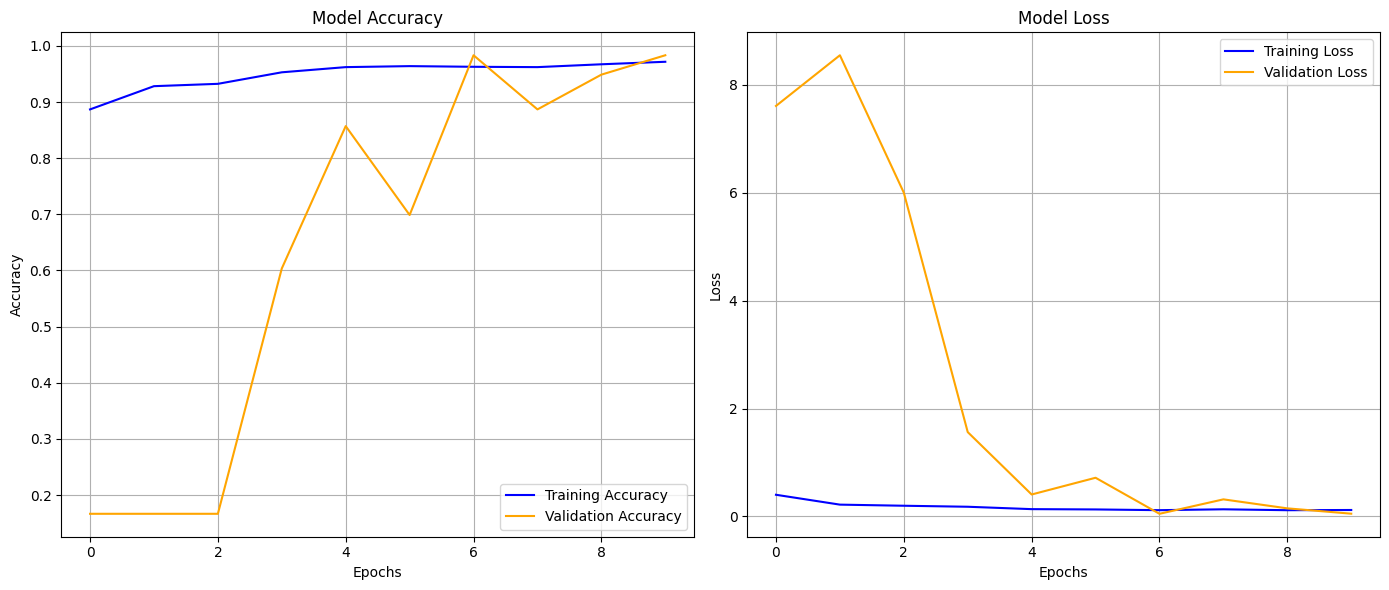

In [ ]:
# --- 9. Performance Visualization ---
print("\nPlotting training history (Accuracy and Loss only)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('accuracy_loss_history.png')

print("\nTraining and Plotting completed successfully!")


Evaluating the model on the validation set...
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 863ms/step


<Figure size 600x600 with 0 Axes>

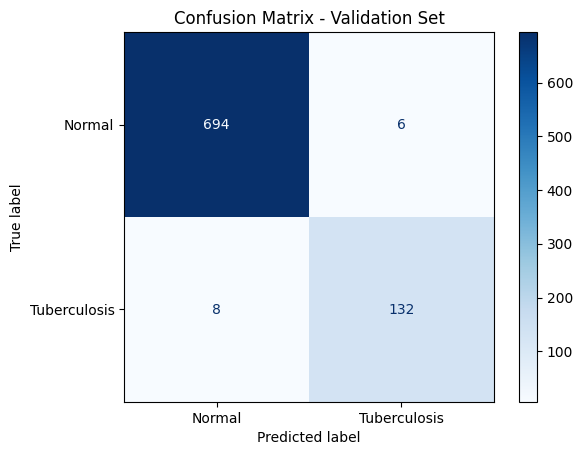


Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       700
Tuberculosis       0.96      0.94      0.95       140

    accuracy                           0.98       840
   macro avg       0.97      0.97      0.97       840
weighted avg       0.98      0.98      0.98       840



In [ ]:
# --- 10. Model Evaluation ---
print("\nEvaluating the model on the validation set...")

# Predictions on validation set
Y_pred = model.predict(validation_generator)
y_pred = (Y_pred > 0.5).astype(int).ravel()

# True labels
y_true = validation_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Tuberculosis'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Validation Set')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Tuberculosis']))